# DeepEval MCP Use Metric — Results Analysis

This notebook analyses the results of the **DeepEval `MCPUseMetric`** evaluation across six LLM models.

Each model was evaluated on ~100 intent-processing test cases. The metric scores each response on a **0–1 scale**
and marks it as `success` (True/False) based on correct MCP tool usage.

**Models evaluated:** Claude Opus 4.5, Claude Sonnet 4.5, Gemini 3 Flash, Gemini 3 Pro, GPT-5 Nano, GPT-5

**Data source:** `results/*.csv` (generated by `deepEval.ipynb`)

In [19]:
%pip install -q pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load & Prepare Data

In [20]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.7)

# ── paths ──────────────────────────────────────────────────────────────
RESULTS_DIR = Path("results")

# ── file → display-name mapping ──────────────────────────────────────
MODEL_FILES = {
    "Claude Opus 4.5":   "deepeval_opus-4-5.csv",
    "Claude Sonnet 4.5": "deepeval_sonnet-4-5.csv",
    "Gemini 3 Flash":    "deepeval_3-flash-preview.csv",
    "Gemini 3 Pro":      "deepeval_gemini-3-pro.csv",
    "GPT-5 Nano":        "deepeval_gpt-5-nano.csv",
    "GPT-5":             "deepeval_gpt_5.csv",
}

# ── consistent colour palette (shared across all notebooks) ──────────
MODEL_COLORS = {
    "Claude Opus 4.5":   "#B39DDB",   # Purple  (Anthropic)
    "Claude Sonnet 4.5": "#CE93D8",   # Light Purple (Anthropic)
    "Gemini 3 Flash":    "#90CAF9",   # Light Blue (Google)
    "Gemini 3 Pro":      "#64B5F6",   # Blue (Google)
    "GPT-5 Nano":        "#A5D6A7",   # Light Green (OpenAI)
    "GPT-5":             "#81C784",   # Green (OpenAI)
}

MODEL_ORDER = list(MODEL_COLORS.keys())

# ── load & concatenate ───────────────────────────────────────────────
frames = []
for display_name, filename in MODEL_FILES.items():
    path = RESULTS_DIR / filename
    tmp = pd.read_csv(path)
    tmp["model"] = display_name
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)

print(f"Total test cases: {len(df)}")
print(f"Models loaded:    {df['model'].nunique()}\n")
print(df.groupby("model", observed=False)["success"].value_counts().unstack(fill_value=0))
df.head()

Total test cases: 601
Models loaded:    6

success            False  True 
model                          
Claude Opus 4.5        2     99
Claude Sonnet 4.5     16     84
Gemini 3 Flash        97      3
Gemini 3 Pro          71     29
GPT-5 Nano             3     97
GPT-5                  0    100


,success,score,reason,model
0,True,0.90,[\n\tThe agent correctly selected the 'create_...,Claude Opus 4.5
1,True,0.85,[\n\tThe agent correctly selected the 'create_...,Claude Opus 4.5
2,True,0.95,[\n\tThe agent correctly selected the 'create_...,Claude Opus 4.5
3,True,0.95,[\n\tThe agent correctly selected the 'create_...,Claude Opus 4.5
4,True,0.90,[\n\tThe agent correctly selected the 'create_...,Claude Opus 4.5


## 2. Score Distribution by Model

/tmp/ipykernel_1041190/2440267459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1041190/2440267459.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")



✓ Chart saved to: deepeval_score_distribution.png


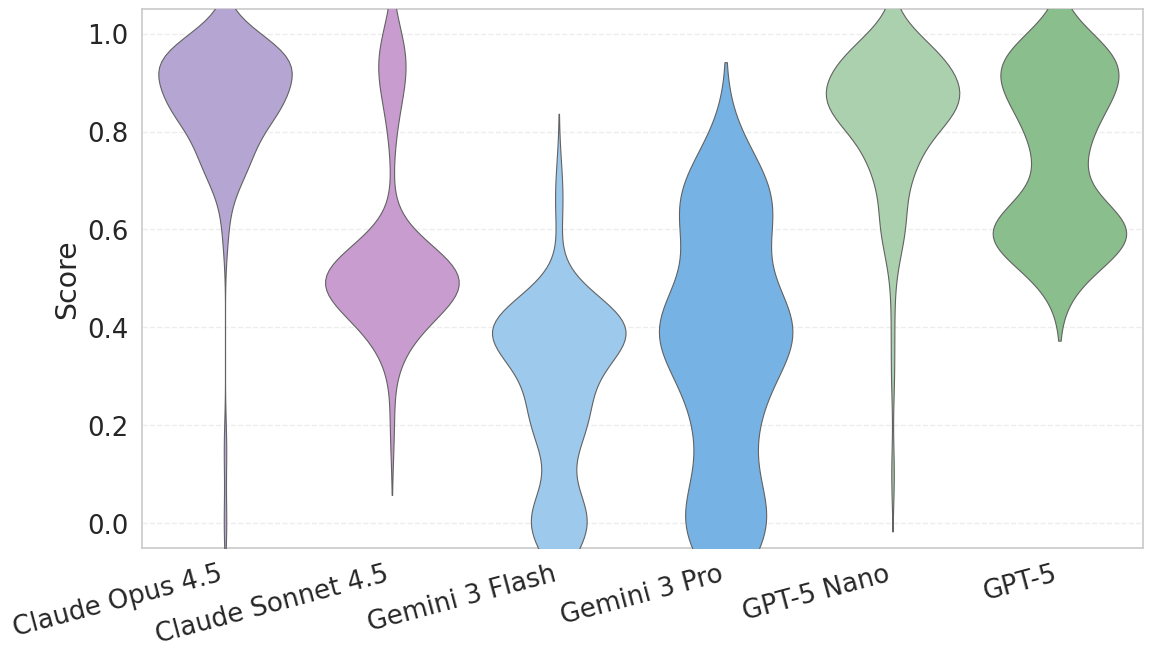

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    data=df, x="model", y="score",
    order=MODEL_ORDER,
    palette=MODEL_COLORS,
    inner="box",
    linewidth=0.8,
    zorder=3,
)


ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(-0.05, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)

plt.tight_layout()
plt.savefig("deepeval_score_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("deepeval_score_distribution.pdf", bbox_inches="tight")
print("\n✓ Chart saved to: deepeval_score_distribution.png")
plt.show()

## 3. Mean Score Comparison

/tmp/ipykernel_1041190/1189595243.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(score_stats.index.astype(str), rotation=15, ha="right")



✓ Chart saved to: deepeval_mean_score.png


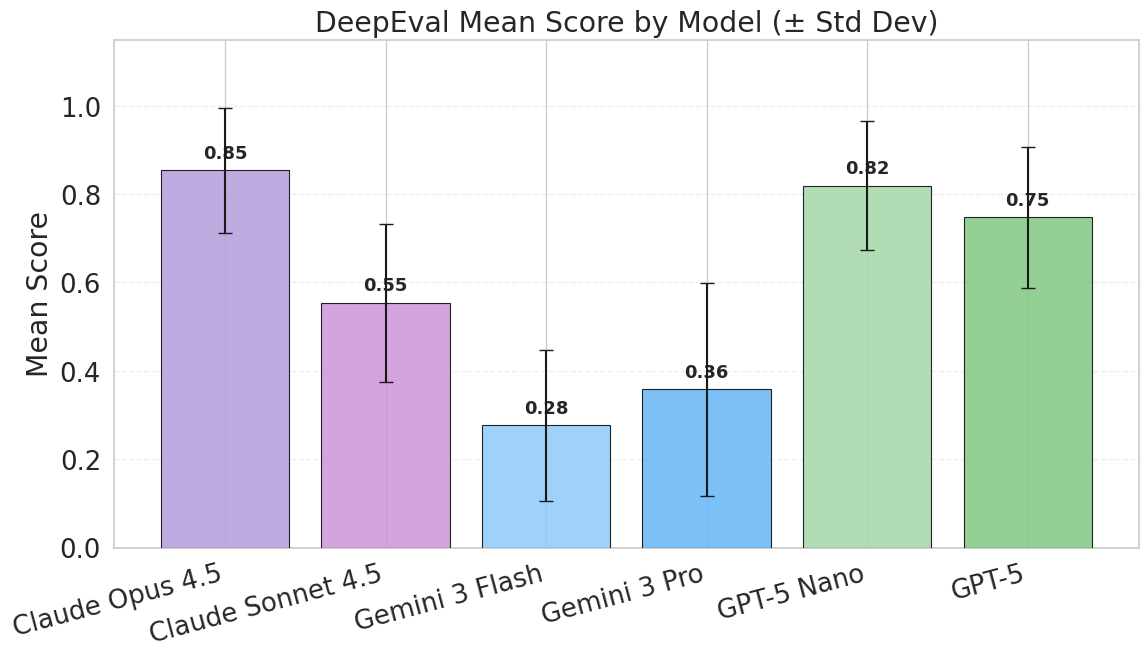

In [22]:
score_stats = (
    df.groupby("model", observed=False)["score"]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    score_stats.index.astype(str),
    score_stats["mean"],
    yerr=score_stats["std"],
    capsize=5,
    color=[MODEL_COLORS[m] for m in score_stats.index],
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

for bar, val in zip(bars, score_stats["mean"]):
    ax.annotate(
        f"{val:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, val),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

ax.set_ylabel("Mean Score")
ax.set_xlabel("")
ax.set_title("DeepEval Mean Score by Model (± Std Dev)")
ax.set_ylim(0, 1.15)
ax.set_xticklabels(score_stats.index.astype(str), rotation=15, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)

plt.tight_layout()
plt.savefig("deepeval_mean_score.png", dpi=300, bbox_inches="tight")
plt.savefig("deepeval_mean_score.pdf", bbox_inches="tight")
print("\n✓ Chart saved to: deepeval_mean_score.png")
plt.show()

## 4. Failure Analysis

In [23]:
# ── summary table ────────────────────────────────────────────────────
failures = df[df["success"] == False].copy()

summary_rows = []
for model in MODEL_ORDER:
    model_df = df[df["model"] == model]
    model_fail = failures[failures["model"] == model]
    total = len(model_df)
    n_fail = len(model_fail)
    rate = (n_fail / total * 100) if total > 0 else 0.0

    # extract short reason snippets (first 150 chars of each unique reason)
    sample_reasons = (
        model_fail["reason"]
        .dropna()
        .str.slice(0, 150)
        .drop_duplicates()
        .head(3)
        .tolist()
    )
    reasons_str = " | ".join(sample_reasons) if sample_reasons else "—"

    summary_rows.append({
        "Model": model,
        "Total": total,
        "Failures": n_fail,
        "Failure Rate (%)": round(rate, 1),
        "Sample Failure Reasons": reasons_str,
    })

summary_df = pd.DataFrame(summary_rows)
print("\n─── Failure Summary by Model ───\n")
display(summary_df)


─── Failure Summary by Model ───



,Model,Total,Failures,Failure Rate (%),Sample Failure Reasons
0,Claude Opus 4.5,101,2,2.0,[\n\tThe agent selected the correct tool (crea...
1,Claude Sonnet 4.5,100,16,16.0,[\n\tThe agent did not use any tools. Accordin...
2,Gemini 3 Flash,100,97,97.0,[\n\tThe agent correctly chose the 'create_ses...
3,Gemini 3 Pro,100,71,71.0,[\n\tThe agent correctly chose the 'create_ses...
4,GPT-5 Nano,100,3,3.0,[\n\tThe agent correctly chose the 'create_ses...
5,GPT-5,100,0,0.0,—
